In [1]:
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
import asyncio

load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

f:\langchain\campusz\graph\langgraph\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class LoopState(TypedDict):

    topic: str
    draft: str
    approved: bool
    feedback: str

checkpointer = InMemorySaver()

In [3]:
def generate_draft(state: LoopState):

    prompt = f'generate 100 words summary on {state['topic']}'
    response = model.invoke(prompt).content 

    return {
        "draft": response
    }

def approval_node(state: LoopState):

    decision = interrupt(
        f"\nDraft:\n\n{state['draft']}\n\nApprove? yes/no"
    )
    return {
        "approved": decision.lower().strip() == "yes"
    }

def feedback_node(state: LoopState):

    feedback = interrupt("Provide improvement feedback:\n")
    return {
        "feedback": feedback
    }

def improve_draft(state: LoopState):

    improve_prompt = f"improvise this text {state['draft']} according to this {state["feedback"]}"
    res = model.invoke(improve_prompt).content
    return {
        "draft": res
    }

def approval_decision(state: LoopState) -> Literal["__end__", "feedback_node"]:

    if state["approved"]:
        return "__end__"
    else:
        return "feedback_node"

In [4]:
graph = StateGraph(LoopState, checkpointer=checkpointer)

graph.add_node("generate_draft", generate_draft)
graph.add_node("approval_node", approval_node)
graph.add_node("feedback_node", feedback_node)
graph.add_node("improve_draft", improve_draft)

graph.set_entry_point("generate_draft")

graph.add_edge("generate_draft","approval_node")

graph.add_conditional_edges("approval_node",approval_decision)
graph.add_edge("feedback_node", "improve_draft")
graph.add_edge("improve_draft", "approval_node")

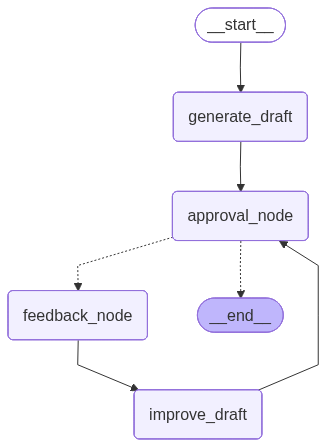

In [5]:
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [10]:
config = {"configurable": {"thread_id": "thread-1"}}
initial_state = {"topic": "interrupts in langgraph"}

In [11]:
while True:

    async for metadata, chunk in workflow.astream(
        initial_state,
        stream_mode=["updates"],
        config=config
    ):
        
        if "__interrupt__" in chunk:

            question = chunk["__interrupt__"][0].value
            print(question)

            user_input = input("> ")
            initial_state = Command(resume=user_input)
            break
    
    else:
        break



Draft:

LangGraph interrupts provide a crucial mechanism to pause graph execution at designated points, typically before or after a node or edge. This is invaluable for implementing human-in-the-loop workflows, allowing users to review AI outputs, provide corrections, or inject new information.

When an interrupt is triggered, the graph's current state is checkpointed, and execution halts, returning control. To resume, the graph is invoked again with the same thread ID, optionally incorporating user-provided updates to the state. This feature enhances debugging, control, and the integration of human oversight into complex, multi-step AI agents, ensuring flexibility and reliability in dynamic applications.

Approve? yes/no
Provide improvement feedback:


Draft:

LangGraph interrupts provide a crucial, programmatic mechanism to halt the execution of a `StateGraph` at designated points, typically configured via `interrupt_before` or `interrupt_after` parameters on specific nodes or edges